# Usage of histogram classes

In [1]:
from histogram_utils import load_group_from_file
import matplotlib.pyplot as plt

def dump_dict(d, prefix='\t|---> '):
    for k, v in d.items():
        print(prefix + f"Key = {k}, Object Type = {type(v)}")


#Load the group of histograms from the file
file_name = "histos/xl.W_QK.histos.pkl"
print(f"Inspecting file {file_name}")
histo_group = load_group_from_file(file_name)

print(type(histo_group))
#HistoGroup
#Has dictionary histogroups: key=(l,h) val=HistogramBase
#Has dictionary metadata: key=(l,h) val=

test_idx = (0, 0) # use 0th head on 0th layer as example
print(f"Inspecting element {test_idx}")
histogram_base = histo_group[test_idx]
print(type(histogram_base))

### HistogramBase

#### Dict `HistogramBase.histograms` (key=str, val="histogram" a 1D np array)
#Access by key:
print("\nHistogramBase contains histograms/arrays: dict HistogramBase.histograms")
dump_dict(histogram_base.histograms)
#The main histogram can be accessed 
h = histogram_base.histograms['P_W'] #by explicit key
h = histogram_base.hist() #default selected, preferred


#### Dict `HistogramBase.stats_values` (key=str, val=typically, but not always float)
print("\nHistogramBase contains stats: dumping HistogramBase.stats_values")
dump_dict(histogram_base.stats_values)
#Individual stats can be accessed 
stat_mean = histogram_base.stats_values['mean']
stat_mean = histogram_base.get_statistic('mean') #preferred

### function `HistogramBase.draw`
print("\nHistogramBase has draw method: calling HistogramBase.draw")
# histogram_base.draw() #or `name='h'`, 
# currently calls plt.bar(), passes kwargs



Inspecting file histos/xl.W_QK.histos.pkl
<class 'histogram_tools.HistogramGroup'>
Inspecting element (0, 0)
<class 'histogram_tools.HistogramBase'>

HistogramBase contains histograms/arrays: dict HistogramBase.histograms
	|---> Key = bins, Object Type = <class 'numpy.ndarray'>
	|---> Key = P_W, Object Type = <class 'numpy.ndarray'>
	|---> Key = SVD, Object Type = <class 'numpy.ndarray'>

HistogramBase contains stats: dumping HistogramBase.stats_values
	|---> Key = sum, Object Type = <class 'numpy.float32'>
	|---> Key = mean, Object Type = <class 'numpy.float32'>
	|---> Key = std, Object Type = <class 'numpy.float32'>
	|---> Key = max, Object Type = <class 'numpy.float32'>
	|---> Key = min, Object Type = <class 'numpy.float32'>
	|---> Key = skew, Object Type = <class 'numpy.float32'>
	|---> Key = kurtosis, Object Type = <class 'numpy.float32'>

HistogramBase has draw method: calling HistogramBase.draw


# Statistics and Moments

In [2]:
from histogram_utils import *
#Compute D_KL ( P || N(0,1)) where P is a HistogramBase
#Call functions directly by key
kl_1 = normality_metrics["kl_vs_empirical_normal"](histogram_base) 
#Use utility, preferred 
kl_2 = kl_vs_empirical_normal(histogram_base)
print(f"Computing D_KL ( P || N(0,1)) method 1 = {kl_1:.3f}, method 2 = {kl_2:.3f}")

print("Extracting metrics:")
#extract directly
print('Extracting metrics')
for k,v in extract_metrics(histogram_base).items():
    print(f"Stat: {k} = {v}")

print('\n\nUpdating and extracting all stats including new metrics')
#or update in-place
extract_metrics_(histogram_base)
for k, v in histogram_base.stats().items():
    print(f"Stat: {k} = {v}")

Computing D_KL ( P || N(0,1)) method 1 = 0.029, method 2 = 0.029
Extracting metrics:
Extracting metrics
Stat: entropy = 3.4089228828630205
Stat: kl_vs_standard_normal = 2.4682634607291556
Stat: kl_vs_empirical_normal = 0.02868107848447164
Stat: kl_normal_vs_standard = 2.5563998222351074
Stat: fit_normal = {'fit_mu': np.float64(3.127533050729762e-06), 'fit_sigma': np.float64(0.03991877239167141)}


Updating and extracting all stats including new metrics
Stat: sum = 51.85404586791992
Stat: mean = 2.025548747042194e-05
Stat: std = 0.04710904881358147
Stat: max = 0.5062251091003418
Stat: min = -0.5594500303268433
Stat: skew = 0.0032705236226320267
Stat: kurtosis = 2.2011170387268066
Stat: entropy = 3.4089228828630205
Stat: kl_vs_standard_normal = 2.4682634607291556
Stat: kl_vs_empirical_normal = 0.02868107848447164
Stat: kl_normal_vs_standard = 2.5563998222351074
Stat: fit_normal = {'fit_mu': np.float64(3.127533050729762e-06), 'fit_sigma': np.float64(0.03991877239167141)}


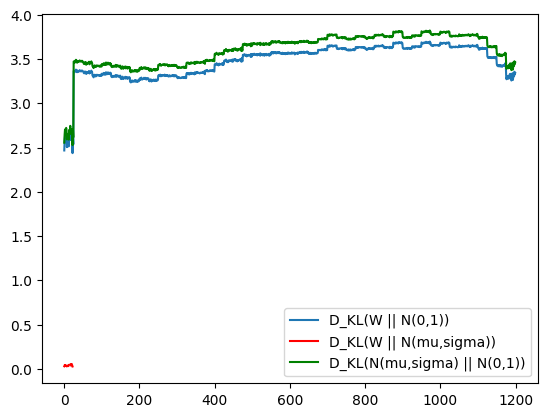

In [3]:
for _, histo_base_obj in histo_group:
    extract_metrics_(histo_base_obj)
t1 = np.array([v for v in histo_group.extract_stats('kl_vs_standard_normal').values()])
t2 = np.array([v for v in histo_group.extract_stats('kl_vs_empirical_normal').values()])
t3 = np.array([v for v in histo_group.extract_stats('kl_normal_vs_standard').values()])
fig, ax = plt.subplots()
ax.plot(t1, label = 'D_KL(W || N(0,1))')
ax.plot(t2, label = 'D_KL(W || N(mu,sigma))', color = 'red')
ax.plot(t3, label = 'D_KL(N(mu,sigma) || N(0,1))', color = 'green')
plt.legend()


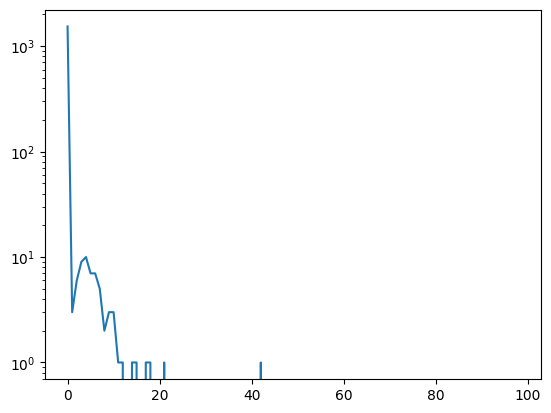

In [15]:
a, b = np.histogram(histogram_base.histograms['SVD'], bins=np.linspace(0,100,100))
plt.plot(a)
plt.yscale("log")